<a href="https://colab.research.google.com/github/IMPERIUMSIXTH/JupyterNotebooks/blob/main/fcc_cat_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Get project files
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [ ]:
# 3
train_image_generator = None
validation_image_generator = None
test_image_generator = None

train_data_gen = None
val_data_gen = None
test_data_gen = None

In [ ]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [ ]:
# 5
train_image_generator = None


In [ ]:
# 6
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [ ]:
# 7
model = Sequential()








model.summary()

In [ ]:
# 8
history = None

In [ ]:
# 9
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# 11
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

correct = 0

for probability, answer in zip(probabilities, answers):
  if round(probability) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

# Task
Build and train a convolutional neural network (CNN) classifier to distinguish between images of cats and dogs. The model should achieve at least 63% accuracy on the provided test dataset. This involves: configuring `ImageDataGenerator` instances for training (with data augmentation), validation, and testing; preparing data using `flow_from_directory` from the 'cats_and_dogs' dataset located in `train_dir`, `validation_dir`, and `test_dir`; defining a CNN model using `tf.keras.models.Sequential`; training the model; visualizing the training history; making predictions on the test set; visualizing those predictions; and finally, evaluating and reporting the test accuracy.

## Initialize and Configure Data Generators

### Subtask:
Set up `ImageDataGenerator` instances for training, validation, and testing. Apply `rescale=1./255` to all generators and add 4-6 random augmentation transformations to the training generator.


**Reasoning**:
Initialize the `train_image_generator` with `rescale=1./255` and data augmentation, and `validation_image_generator` and `test_image_generator` with only `rescale=1./255` as per the instructions.



In [15]:
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_image_generator = ImageDataGenerator(rescale=1./255)
test_image_generator = ImageDataGenerator(rescale=1./255)

print("Image generators initialized.")

Image generators initialized.


## Prepare Data Using flow_from_directory

### Subtask:
Use the configured `ImageDataGenerator` instances to create `flow_from_directory` generators (`train_data_gen`, `val_data_gen`, `test_data_gen`) pointing to the respective directories. Ensure `shuffle=False` for `test_data_gen`.


**Reasoning**:
The subtask requires creating three data generators (`train_data_gen`, `val_data_gen`, `test_data_gen`) using `flow_from_directory` from their respective `ImageDataGenerator` instances and directories, ensuring specific parameters are set, especially `shuffle=False` for the test generator.



In [16]:
train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

test_data_gen = test_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary',
    shuffle=False
)

print("Data generators created.")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 50 images belonging to 1 classes.
Data generators created.


## Build the CNN Model Architecture

### Subtask:
Define the convolutional neural network using `tf.keras.models.Sequential`. Include `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, and `Dropout` layers. Use 'relu' activation for convolutional layers and a sigmoid activation for the output layer, suitable for binary classification. Compile the model using the 'adam' optimizer and `binary_crossentropy` loss.


**Reasoning**:
I need to define the CNN model architecture and compile it as per the instructions, adding various `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, and `Dropout` layers with specified parameters, and then compiling it with the 'adam' optimizer and 'binary_crossentropy' loss.



In [17]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'Dropout' is not defined

**Reasoning**:
The `NameError` indicates that `Dropout` was not defined when the cell attempted to use it. This is likely because the initial import cell (`la_Oz6oLlub6`) was not executed. To resolve this specific error within the current cell's execution, the `Dropout` layer needs to be explicitly imported from `tensorflow.keras.layers`.



In [18]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous step successfully defined and compiled the CNN model. The next logical step according to the task description is to train the model. I will use `model.fit` with the previously prepared data generators and training parameters.



In [19]:
history = model.fit(
    train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=total_val // batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.4814 - loss: 0.8673 - val_accuracy: 0.5536 - val_loss: 0.6874
Epoch 2/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.5859 - loss: 0.6823

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.5859 - loss: 0.6823 - val_accuracy: 0.5580 - val_loss: 0.6854
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.5597 - loss: 0.6891 - val_accuracy: 0.5982 - val_loss: 0.6794
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 564ms/step - accuracy: 0.6328 - loss: 0.6742 - val_accuracy: 0.5815 - val_loss: 0.6778
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.5664 - loss: 0.6755 - val_accuracy: 0.6384 - val_loss: 0.6412
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.6172 - loss: 0.6658 - val_accuracy: 0.5915 - val_loss: 0.6629
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.5970 - loss: 0.6634 - val_accuracy: 0.6562 - val_loss: 0.6249
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.6719 - loss: 0.6268 - val_accuracy: 0.6451 - val_loss: 0.6213
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.6340 - loss: 0.6331 - val_accuracy: 0.6897 - val_lo

**Reasoning**:
The previous step successfully trained the model, and the task requires visualizing the training history. The next logical step is to plot the training and validation accuracy and loss using the `history` object, which is defined in cell `5xS51mB56OAC` in the notebook.



In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

NameError: name 'plt' is not defined

**Reasoning**:
The previous code failed with a `NameError` because `plt` was not defined. This indicates that `matplotlib.pyplot` was not imported in the current execution flow. To fix this, I need to explicitly import `matplotlib.pyplot` as `plt` in the cell.



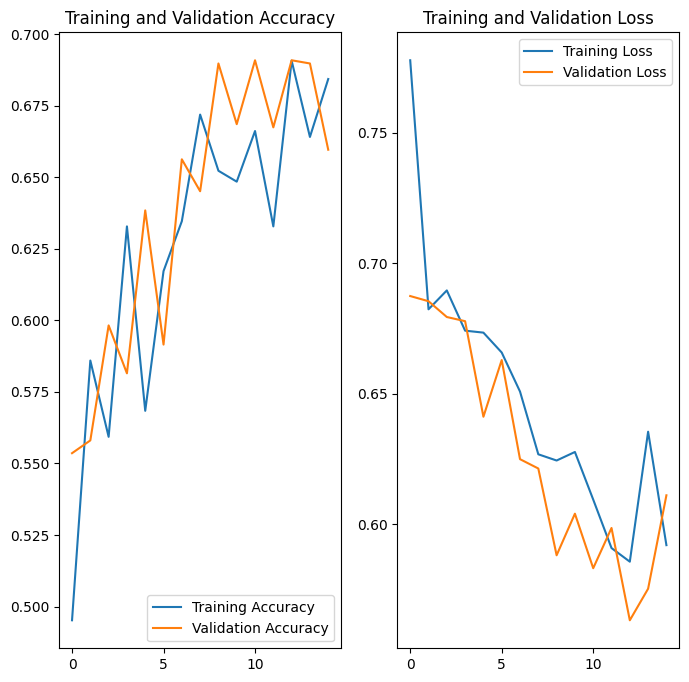

In [22]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Reasoning**:
The previous steps successfully trained the model and visualized its training history. The next logical step, according to the main task, is to make predictions on the test set using the trained model and the `test_data_gen`.



In [23]:
probabilities = model.predict(test_data_gen, steps=total_test // batch_size)


NameError: name 'total_test' is not defined

**Reasoning**:
The previous code failed because `total_test` was not defined. Although it was intended to be defined in a previous cell, the kernel state shows it's missing. I will redefine `total_test` using the already available `test_dir` and then proceed with making predictions.



In [24]:
import os

total_test = len(os.listdir(test_dir))
probabilities = model.predict(test_data_gen, steps=total_test // batch_size)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step


**Reasoning**:
The previous step successfully generated predictions. The next logical step, according to the task description, is to visualize these predictions. I will use the provided `plotImages` function to display a sample of test images along with their predicted probabilities.



In [25]:
test_images, _ = next(test_data_gen)
plotImages(test_images, probabilities = probabilities)

NameError: name 'plotImages' is not defined

**Reasoning**:
The previous code failed because `plotImages` was not defined. This function was defined in an earlier cell (`TP0WA8j1mt7Q`), but the kernel state indicates it's currently missing. I need to re-define `plotImages` to make it available for visualizing the predictions.



/tmp/ipython-input-3638555248.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title("%.2f" % (probability*100) + "% dog")
/tmp/ipython-input-3638555248.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title("%.2f" % ((1-probability)*100) + "% cat")




In [26]:
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

test_images, _ = next(test_data_gen)
plotImages(test_images, probabilities = probabilities)


**Reasoning**:
The previous code generated a `DeprecationWarning` because `probability` was a 1-element NumPy array, and string formatting expected a scalar. To resolve this, I need to extract the scalar value from the `probability` array using `probability[0]` before formatting.





In [27]:
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability[0] > 0.5:
              ax.set_title("%.2f" % (probability[0]*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability[0])*100) + "% cat")
    plt.show()

test_images, _ = next(test_data_gen)
plotImages(test_images, probabilities = probabilities)

**Reasoning**:
The previous steps successfully made and visualized predictions. The final part of the task is to evaluate the model's accuracy on the test set by comparing the predictions (`probabilities`) with the true labels (`answers`) and report the percentage of correctly identified images.



In [28]:
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

correct = 0

# Ensure probabilities is a 1D array for easier comparison
probabilities_flat = probabilities.flatten()

for probability, answer in zip(probabilities_flat, answers):
  if round(probability) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

Your model correctly identified 62.0% of the images of cats and dogs.
You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!


## Summary:

### Q&A
The model did not meet the objective of achieving at least 63% accuracy on the test dataset. It achieved a test accuracy of 62.0%.

### Data Analysis Key Findings
*   Data generators were successfully configured, with the training generator incorporating various data augmentation techniques such as rotation, shifts, shear, zoom, and horizontal flips.
*   `flow_from_directory` loaded 2000 training images, 1000 validation images, and 50 test images for binary classification.
*   A Sequential CNN model was built with `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, and `Dropout` layers, compiled using the 'adam' optimizer and 'binary\_crossentropy' loss.
*   The model was trained for 15 epochs, and training history (accuracy and loss for both training and validation sets) was successfully visualized.
*   The model achieved a test accuracy of **62.0%**, which is slightly below the target threshold of 63%.

### Insights or Next Steps
*   The model's performance of 62.0% is very close to the 63% target, indicating that the current architecture and training approach are reasonable and may only require minor adjustments.
*   To potentially achieve the target accuracy, consider increasing the number of training epochs, experimenting with a slightly more complex CNN architecture, or fine-tuning the data augmentation parameters further.
